<a href="https://colab.research.google.com/github/akul-bharadwaj/various-agents/blob/main/Insurance_Claim_Processing_Multi_Agents_with_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
###############################################################
# LangGraph Version
# Same Insurance Workflow
###############################################################

# =============================================================
# Install
# =============================================================

!pip -q install -U langgraph langchain-openai openai

# =============================================================
# Imports
# =============================================================

import base64
from typing import TypedDict

from google.colab import files

from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# =============================================================
# API KEY
# =============================================================

import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI API Key: ")

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.environ["OPENAI_API_KEY"]
)

# =============================================================
# Upload Image
# =============================================================

uploaded = files.upload()

IMAGE_PATH = list(uploaded.keys())[0]

with open(IMAGE_PATH,"rb") as f:
    image_b64 = base64.b64encode(f.read()).decode()

# =============================================================
# Sample Inputs
# =============================================================

policy = """
ABC Motor Insurance Policy

Coverage

Front bumper

Rear bumper

Headlights

Hood

Windshield

Maximum Claim Amount ₹2,00,000

Deductible ₹5,000

Exclusions

Driving under influence

Racing

Intentional damage
"""

incident = """
Yesterday another vehicle collided with my car
while I was waiting at a traffic signal.

Front bumper,
hood,
right headlight damaged.

Police complaint filed.
"""

# =============================================================
# Shared State
# =============================================================

class InsuranceState(TypedDict):

    image_b64: str

    policy: str

    incident: str

    vision_report: str

    policy_report: str

    incident_report: str

    assessment: str

    decision: str

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 16.1 MB/s eta 0:00:00
Enter OpenAI API Key: ··········


Saving photo-1673187139612-6bf684a74815.jpg to photo-1673187139612-6bf684a74815.jpg


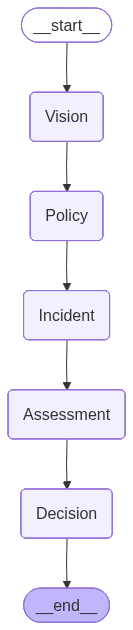


===== VISION AGENT =====

Damaged Parts:
- Front left fender
- Front left headlight assembly
- Front bumper (left side)
- Hood (left side)

Severity:
- The damage appears moderate to severe, with visible deformation and crumpling of the fender and bumper.
- The headlight assembly is broken and likely non-functional.
- The hood is bent and misaligned, indicating significant impact.

Observations:
- There is visible debris on the ground in front of the damaged area.
- The damage is localized to the front left corner of the vehicle.
- The wheel/tire do not show obvious immediate damage but inspection would be needed for suspension or alignment issues.

===== POLICY AGENT =====

Covered Items:
- Front bumper
- Rear bumper
- Headlights
- Hood
- Windshield

Exclusions:
- Driving under influence
- Racing
- Intentional damage

Deductible:
- ₹5,000

Maximum Claim Amount:
- ₹2,00,000

===== INCIDENT AGENT =====

A vehicle collided with your car while you were waiting at a traffic signal. The fr

In [2]:
# =============================================================
# Vision Agent
# =============================================================

def vision_agent(state):

    response = llm.invoke(

        [

        SystemMessage(
            content="""
            You are an automobile damage inspection expert.

            Identify

            damaged parts

            severity

            observations only.
            """
        ),

        HumanMessage(

            content=[

                {
                    "type":"text",

                    "text":"Inspect this vehicle."
                },

                {
                    "type":"image_url",

                    "image_url":{

                        "url":f"data:image/png;base64,{state['image_b64']}"

                    }

                }

            ]

        )

        ]

    )

    state["vision_report"] = response.content

    print("\n===== VISION AGENT =====\n")
    print(response.content)

    return state

# =============================================================
# Policy Agent
# =============================================================

def policy_agent(state):

    response = llm.invoke(

        [

            SystemMessage(

                content="""
                You are an insurance policy expert.

                Summarize

                covered items

                exclusions

                deductible

                claim amount.
                """

            ),

            HumanMessage(

                content=state["policy"]

            )

        ]

    )

    state["policy_report"] = response.content

    print("\n===== POLICY AGENT =====\n")
    print(response.content)

    return state

# =============================================================
# Incident Agent
# =============================================================

def incident_agent(state):

    response = llm.invoke(

        [

            SystemMessage(

                content="""
                You summarize accident descriptions.
                """

            ),

            HumanMessage(

                content=state["incident"]

            )

        ]

    )

    state["incident_report"] = response.content

    print("\n===== INCIDENT AGENT =====\n")
    print(response.content)

    return state

# =============================================================
# Assessment Agent
# =============================================================

def assessment_agent(state):

    prompt = f"""

Vehicle Inspection

{state["vision_report"]}


Policy

{state["policy_report"]}


Incident

{state["incident_report"]}


Determine

Covered damages

Exclusions

Claim validity

Explain reasoning.

"""

    response = llm.invoke(

        [

            SystemMessage(

                content="You are a senior insurance assessor."

            ),

            HumanMessage(

                content=prompt

            )

        ]

    )

    state["assessment"] = response.content

    print("\n===== CLAIM ASSESSMENT =====\n")
    print(response.content)

    return state

# =============================================================
# Decision Agent
# =============================================================

def decision_agent(state):

    response = llm.invoke(

        [

            SystemMessage(

                content="""
                You are the final insurance authority.

                Return

                Decision

                Reason

                Confidence

                Next Step

                Decision must be one of

                APPROVED

                REJECTED

                MANUAL REVIEW
                """

            ),

            HumanMessage(

                content=state["assessment"]

            )

        ]

    )

    state["decision"] = response.content

    print("\n===== DECISION =====\n")
    print(response.content)

    return state

# =============================================================
# Build Graph
# =============================================================

builder = StateGraph(InsuranceState)

builder.add_node("Vision", vision_agent)

builder.add_node("Policy", policy_agent)

builder.add_node("Incident", incident_agent)

builder.add_node("Assessment", assessment_agent)

builder.add_node("Decision", decision_agent)

builder.add_edge(START,"Vision")

builder.add_edge("Vision","Policy")

builder.add_edge("Policy","Incident")

builder.add_edge("Incident","Assessment")

builder.add_edge("Assessment","Decision")

builder.add_edge("Decision",END)

graph = builder.compile()

# =============================================================
# Visualize Graph
# =============================================================

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

# =============================================================
# Execute
# =============================================================

initial_state = {

    "image_b64":image_b64,

    "policy":policy,

    "incident":incident,

    "vision_report":"",

    "policy_report":"",

    "incident_report":"",

    "assessment":"",

    "decision":""

}

result = graph.invoke(initial_state)

print("\n")
print("="*80)
print("FINAL DECISION")
print("="*80)

print(result["decision"])